In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
path='C:/Users/MAXMU/Desktop/DASTURLASH/Data/Salary_Data.csv'
data=pd.read_csv('C:/Users/MAXMU/Desktop/DASTURLASH/Data/Salary_Data.csv')

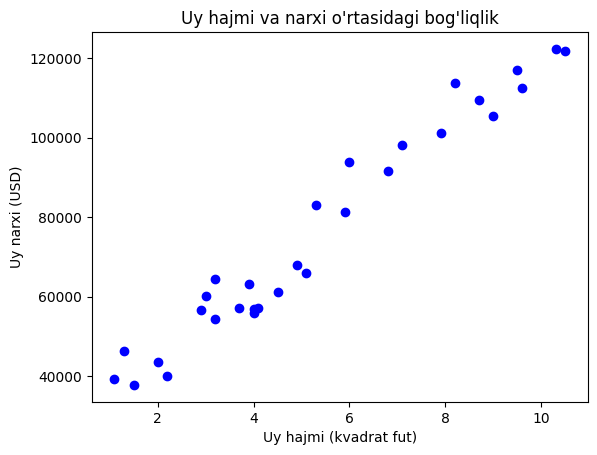

In [3]:
# Scatter grafik
plt.scatter(data["YearsExperience"], data["Salary"], color="blue")
plt.title("Uy hajmi va narxi o'rtasidagi bog'liqlik")
plt.xlabel("Uy hajmi (kvadrat fut)")
plt.ylabel("Uy narxi (USD)")
plt.show()

In [4]:
# Xususiyatlar (X) va nishon (y)ni aniqlash
X = data[["YearsExperience"]]
y = data["Salary"]

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
# O'rgatish va test to'plamlariga bo'lish
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# O'rgatish va test ma'lumotlarini ko'rsatish
X_train

,YearsExperience
28,10.3
24,8.7
12,4.0
0,1.1
4,2.2
16,5.1
5,2.9
13,4.1
11,4.0
22,7.9


In [7]:
from sklearn.linear_model import LinearRegression

In [8]:
data.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [9]:
# Modelni ishga tushirish
model = LinearRegression()

In [10]:
# Modelni o'rgatish
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:
# Koeffitsientlarni chiqarish
print("Intercept (Beta_0):", model.intercept_)
print("Slope (Beta_1):", model.coef_[0])

Intercept (Beta_0): 25321.583011776813
Slope (Beta_1): 9423.815323030976


In [12]:
# Test to'plamida narxlarni bashorat qilish
y_pred = model.predict(X_test)
y_pred

array([115790.21011287,  71498.27809463, 102596.86866063,  75267.80422384,
        55477.79204548,  60189.69970699])

In [13]:
# Natijalarni ko'rsatish
natijalar = pd.DataFrame({"Haqiqiy": y_test.values, "Bashorat qilingan": y_pred})
natijalar

,Haqiqiy,Bashorat qilingan
0,112635.0,115790.210113
1,67938.0,71498.278095
2,113812.0,102596.868661
3,83088.0,75267.804224
4,64445.0,55477.792045
5,57189.0,60189.699707


In [14]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error

In [15]:
# O'rtacha kvadratik xato (MSE) va R-kvadratni hisoblash
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("O'rtacha kvadratik xato (MSE):", mse)
print("O'rtacha absolyut xato (MSE):", mae)
print("R-kvadrat (R^2):", r2)

O'rtacha kvadratik xato (MSE): 49830096.85590839
O'rtacha absolyut xato (MSE): 6286.453830757749
R-kvadrat (R^2): 0.9024461774180497


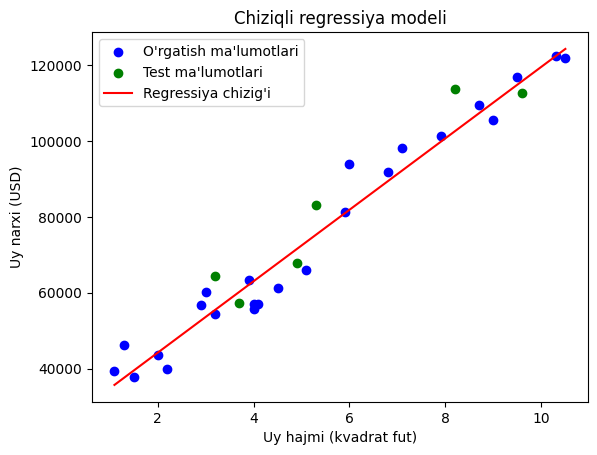

In [16]:
# O'rgatish ma'lumotlari va regressiya chizig'i grafikasi
plt.scatter(X_train, y_train, color="blue", label="O'rgatish ma'lumotlari")
plt.scatter(X_test, y_test, color="green", label="Test ma'lumotlari")
plt.plot(X, model.predict(X), color="red", label="Regressiya chizig'i")
plt.title("Chiziqli regressiya modeli")
plt.xlabel("Uy hajmi (kvadrat fut)")
plt.ylabel("Uy narxi (USD)")
plt.legend()
plt.show()

In [17]:
# Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

In [18]:
# Random Forest Regressor
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

In [19]:
# Support Vector Regression
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

In [20]:
# bir xil o'lchamga keltirish
sc_X = StandardScaler()
sc_y = StandardScaler()

X_train_scaled = sc_X.fit_transform(X_train)
X_test_scaled = sc_X.transform(X_test)

y_train_scaled = sc_y.fit_transform(y_train.values.reshape(-1,1)).ravel()

In [21]:
# SVR model:
svr_model = SVR(kernel='rbf')
svr_model.fit(X_train_scaled, y_train_scaled)

y_pred_svr_scaled = svr_model.predict(X_test_scaled)

# qayta original qiymatga o'tkazish
y_pred_svr = sc_y.inverse_transform(y_pred_svr_scaled.reshape(-1,1)).ravel()

In [22]:
# Hammasini baholash
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_model(name, y_test, y_pred):
    print(f"\n{name}")
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("R2:", r2_score(y_test, y_pred))

In [23]:
# Random Forest predictionni yaratish
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [24]:
y_pred_rf = rf_model.predict(X_test)

In [25]:
evaluate_model("Random Forest", y_test, y_pred_rf)


Random Forest
MSE: 63721129.712950476
MAE: 6872.007670634925
R2: 0.8752513004196268


In [26]:
# Random Forest
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 👇 SHU YERDA YARATILADI
y_pred_rf = rf_model.predict(X_test)

# Evaluation
evaluate_model("Random Forest", y_test, y_pred_rf)


Random Forest
MSE: 63721129.712950476
MAE: 6872.007670634925
R2: 0.8752513004196268


In [27]:
# Natijalar:
evaluate_model("Linear Regression", y_test, y_pred)
evaluate_model("Decision Tree", y_test, y_pred_dt)
evaluate_model("Random Forest", y_test, y_pred_rf)
evaluate_model("SVR", y_test, y_pred_svr)


Linear Regression
MSE: 49830096.85590839
MAE: 6286.453830757749
R2: 0.9024461774180497

Decision Tree
MSE: 101047709.83333333
MAE: 8640.166666666666
R2: 0.8021759743735162

Random Forest
MSE: 63721129.712950476
MAE: 6872.007670634925
R2: 0.8752513004196268

SVR
MSE: 54331632.86712574
MAE: 5800.142665068165
R2: 0.8936333901049043


In [28]:
models = {
    "Linear": r2_score(y_test, y_pred),
    "Decision Tree": r2_score(y_test, y_pred_dt),
    "Random Forest": r2_score(y_test, y_pred_rf),
    "SVR": r2_score(y_test, y_pred_svr)
}

best_model = max(models, key=models.get)

print("Eng yaxshi model:", best_model)

Eng yaxshi model: Linear
